In [1]:
import torch
from torch.utils import data
import matplotlib.pyplot as plt
import numpy as np

from utils.dataMakerMem import DataHandler
from utils.dataMaker import DataHandler as DataHandlerOrig
import utils.plotter as plotter
import datasets.dataLoader as dataLoader
import config

## Simulated Data

### Generate Spectrogams

Here we generate spectrograms from the .mat files which contain the results of the [KRAKEN](https://oalib-acoustics.org/models-and-software/normal-modes/) simulation.

In [2]:
# Load simulated data into data object
handler = DataHandler(path=config.mat_data, sampled_noise_path=config.sample_noise_mat, fs_desired=config.fs)

In [3]:
# Normalize
#handler.l2norm()

# Create spectrograms
handler.create_and_save_signals(split=True, rand_shift=True, verbose=True);

  0%|          | 0/152696 [00:00<?, ?it/s]

In [ ]:
print("Saving")
# Save data
handler.save_split_h5(train_path=config.train_data, 
                      val_path=config.val_data, 
                      test_path=config.test_data, 
                      train_size=0.8, 
                      test_size=0.1, 
                      val_size=0.1, 
                      shuffle=True)

del handler

### Visualize Data

Load the validation data.

In [2]:
X, y = dataLoader.load_h5(config.test_data)

Show some distributions of simulation parameters. These could be NOT uniform if the duration filer was used during simulation.

Text(0, 0.5, 'Number of Examples')

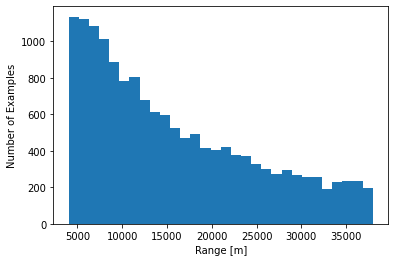

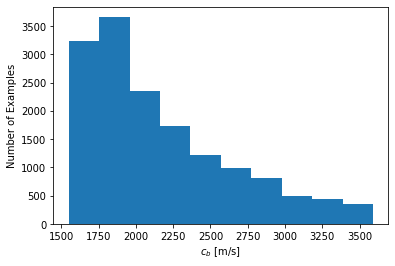

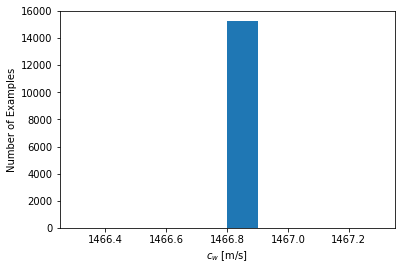

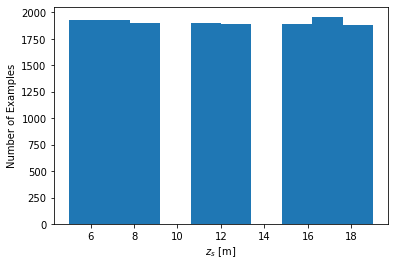

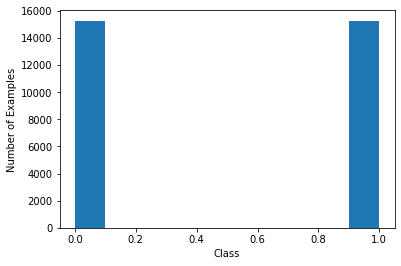

In [5]:
plt.figure()
plt.hist(y[y[:,0] != -1, 0], bins='auto')
plt.xlabel("Range [m]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,1] != -1, 1])
plt.xlabel("$c_{b}$ [m/s]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,2] != -1, 2])
plt.xlabel("$c_{w}$ [m/s]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,3] != -1, 3])
plt.xlabel("$z_{s}$ [m]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,4] != -1, 4])
plt.xlabel("Class")
plt.ylabel("Number of Examples")

Plot the different classes

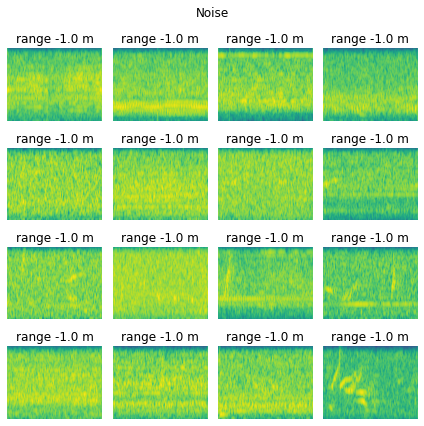

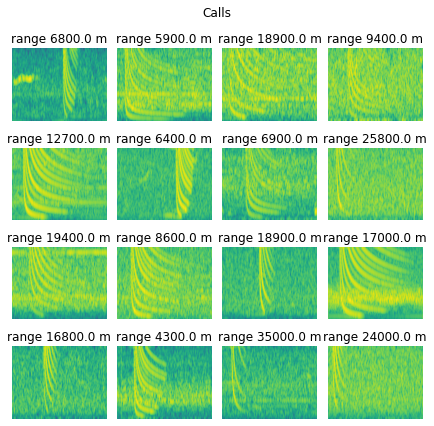

In [3]:
# Plot examples from noise class
plotter.plot_grid(X[np.where(y[:,4] == 0)], y[np.where(y[:,4] == 0),0].squeeze(), label_text="range", sub_titles=True, title="Noise", dim=(4,4))

# Plot examples from call class
plotter.plot_grid(X[np.where(y[:,4] == 1)], y[np.where(y[:,4] == 1),0].squeeze(), label_text="range", sub_titles=True, title="Calls", dim=(4,4))

### Get Training Set Statistics

In [7]:
# Create dataset and dataloader
dataset_g = dataLoader.Gunshot(dir_path=config.train_data, transform=dataLoader.get_image_transforms()['eval'], max_range=config.max_range, from_time=True, squeeze=False, hpf=False)
dataset_n = dataLoader.Noise(dir_path=config.sample_noise, transform=dataLoader.get_image_transforms()['eval'], squeeze=False, from_time=True, hpf=False)

dataset = dataLoader.CustomConcatDataset((dataset_g, dataset_n))
g_len = dataset_g.__len__()
gn_len = g_len + dataset_n.__len__()
g_indices = list(range(g_len))
n_indices = list(range(g_len, gn_len))

dataloader = data.DataLoader(dataset, 
                             #batch_size=128, 
                             #drop_last=False, 
                             #shuffle=True, 
                             num_workers=26, 
                             batch_sampler=dataLoader.MixedBatchSampler(g_indices, n_indices, 128, dataset_g))

In [8]:
b = iter(dataloader)

In [9]:
a = next(b)
print(a[0][0,0,...])
#print(a[0].squeeze().mean(axis=2, keepdims=True))
#print(torch.sqrt(torch.sum(a[0] ** 2, axis=1, keepdims=True)))

tensor([[ 0.5374,  0.7297,  0.8185,  ...,  0.9512,  0.8845,  0.7846],
        [ 0.4885,  0.6910,  0.7832,  ...,  0.9161,  0.8500,  0.7452],
        [ 0.4454,  0.6518,  0.7433,  ...,  0.8643,  0.8057,  0.6997],
        ...,
        [-1.9646, -1.4567, -0.9325,  ...,  0.3895,  0.5616,  0.5802],
        [-2.3054, -1.4817, -0.8423,  ...,  0.4461,  0.6056,  0.6258],
        [-2.5598, -1.2717, -0.6553,  ...,  0.4736,  0.6108,  0.6289]])


In [9]:
dl = dataLoader.get_dataloaders(data_dir=config.data_dir,
                                batch_size=128,
                                max_range=config.max_range,
                                shuffle=True,
                                transform=dataLoader.get_image_transforms(),
                                squeeze=True,
                                hpf=False)

In [ ]:
from tqdm.notebook import tqdm

# Placeholders
psum = torch.tensor([0.0])
psum_sq = torch.tensor([0.0])

# Calculate sum of data and sum of squared data
for inputs, _, _ in tqdm(dataloader):
    psum += inputs.sum(axis=(0,2,3))
    psum_sq += (inputs ** 2).sum(axis=(0,2,3))

# Calculate mean and std via:
# var = E[X^2] - E[X]^2
# std = sqrt(var)
count = len(dataset)*dataset.datasets[0].imsize[0]*dataset.datasets[0].imsize[1]
total_mean = psum / count
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

print('mean: ', total_mean)
print('std: ', total_std)

In [4]:
from tqdm.notebook import tqdm

# Calculate sum of data and sum of squared data

# Placeholders
psum = torch.zeros((dataset.datasets[0].imsize[0],), dtype=torch.float32)
psum_sq = torch.zeros((dataset.datasets[0].imsize[0],), dtype=torch.float32)
for inputs, _, _ in tqdm(dataloader):
    psum += inputs.sum(axis=(0,1,3))
    psum_sq += (inputs ** 2).sum(axis=(0,1,3))

# Calculate mean and std via:
# var = E[X^2] - E[X]^2
# std = sqrt(var)
count = len(dataset)*dataset.datasets[0].imsize[1]
total_mean = psum / count
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

print('mean: ', total_mean)
print('std: ', total_std)

  0%|          | 0/1909 [00:00<?, ?it/s]

mean:  tensor([-80.2070, -78.6510, -77.4232, -76.1601, -74.8393, -73.5717, -72.3804,
        -71.2590, -70.2022, -69.2055, -68.2657, -67.3783, -66.5415, -65.7552,
        -65.0179, -64.3293, -63.6917, -63.1071, -62.5723, -62.0871, -61.6475,
        -61.2524, -60.8979, -60.5809, -60.2998, -60.0520, -59.8350, -59.6453,
        -59.4797, -59.3362, -59.2118, -59.1048, -59.0137, -58.9335, -58.8632,
        -58.8036, -58.7531, -58.7075, -58.6682, -58.6343, -58.6024, -58.5715,
        -58.5430, -58.5157, -58.4895, -58.4637, -58.4388, -58.4159, -58.3946,
        -58.3741, -58.3548, -58.3362, -58.3193, -58.3026, -58.2854, -58.2665,
        -58.2454, -58.2247, -58.2055, -58.1868, -58.1678, -58.1491, -58.1315,
        -58.1143, -58.0966, -58.0766, -58.0548, -58.0307, -58.0049, -57.9778,
        -57.9497, -57.9198, -57.8862, -57.8449, -57.7959, -57.7427, -57.6877,
        -57.6303, -57.5692, -57.5029, -57.4267, -57.3484, -57.2702, -57.1952,
        -57.1254, -57.0605, -56.9997, -56.9447, -56.8940,

## Experimental Data

### Generate Spectrograms

In [ ]:
# Load experimental data into data object
handler = DataHandlerOrig(path=config.warped_dir, data_dir=data_dir, mode='wav', fs_desired=600)

# Make each audio waveform have mean=0 and var=1
#handler.normalize_wav()
handler.l2norm()

# Create spectrograms
#handler.create_spectrograms(rand_shift=False, nperseg=62, noverlap=46, nfft=451, verbose=True)
handler.create_signals(rand_shift=False, verbose=True);

# Save data
handler.save_h5(config.exp_data)

del handler

### Visualize Data

Load the experimental warped data.

In [ ]:
X_w, y_w = dataLoader.load_h5(config.exp_data)

Plot some samples.

In [ ]:
# Make plot
plotter.plot_grid(X_w, y_w[:,0], label_text="range:", sub_titles=True, title="Warped Calls", dim=(4,4), randomize=True)